Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving Telco-Customer-Churn-rawdata.csv to Telco-Customer-Churn-rawdata (1).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract 

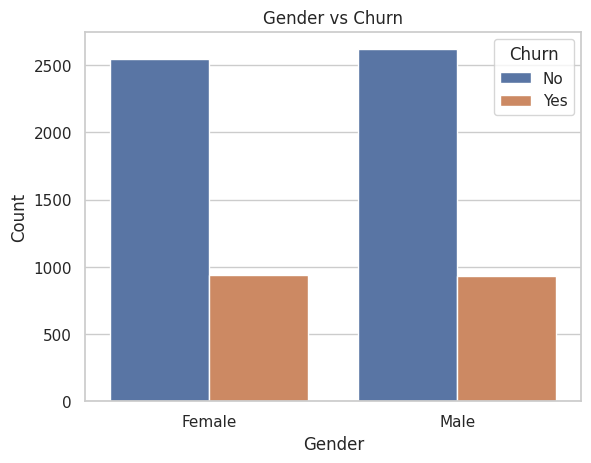

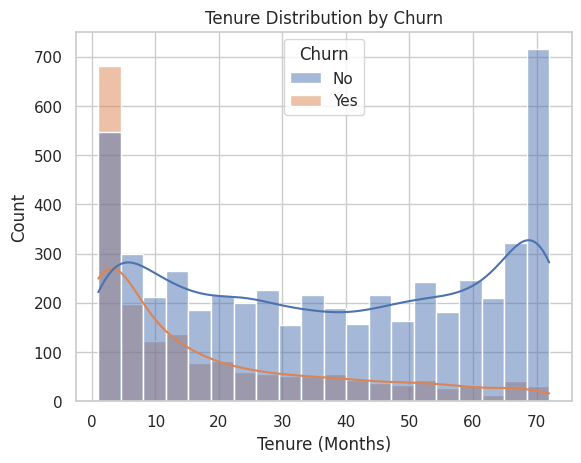

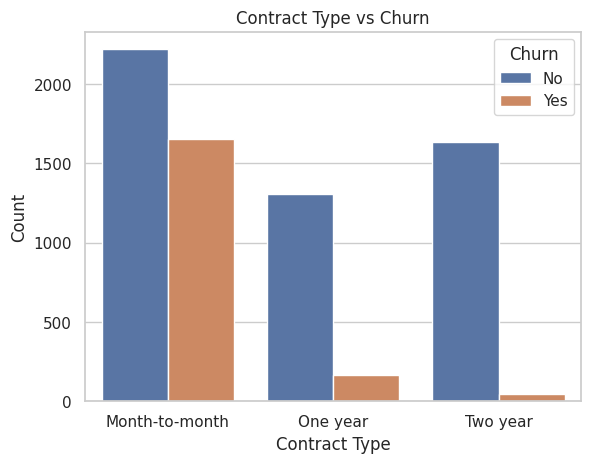

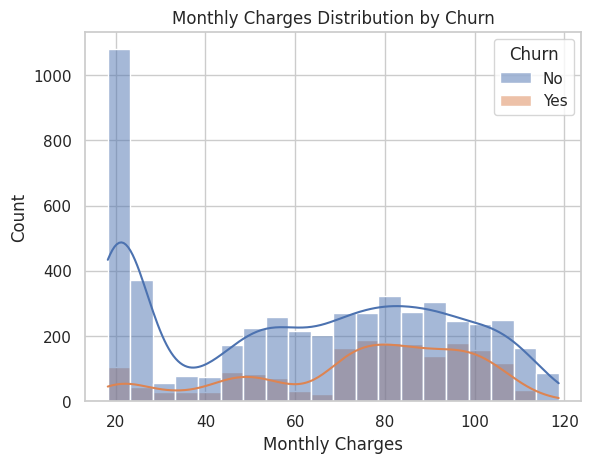

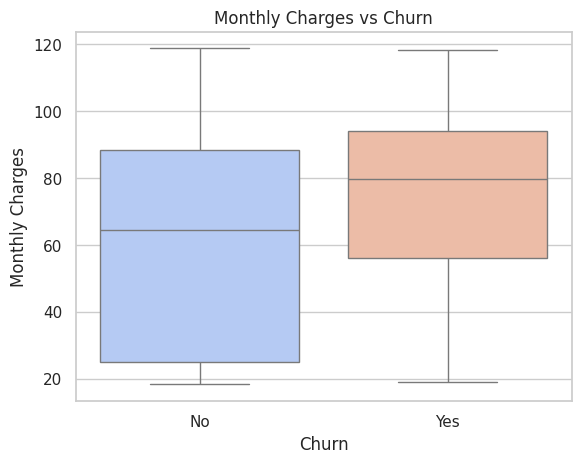

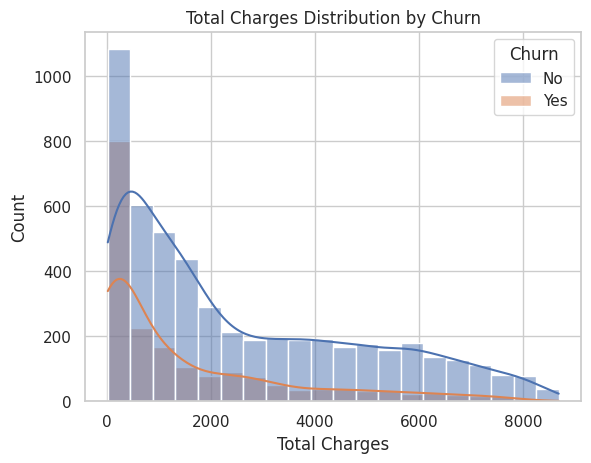

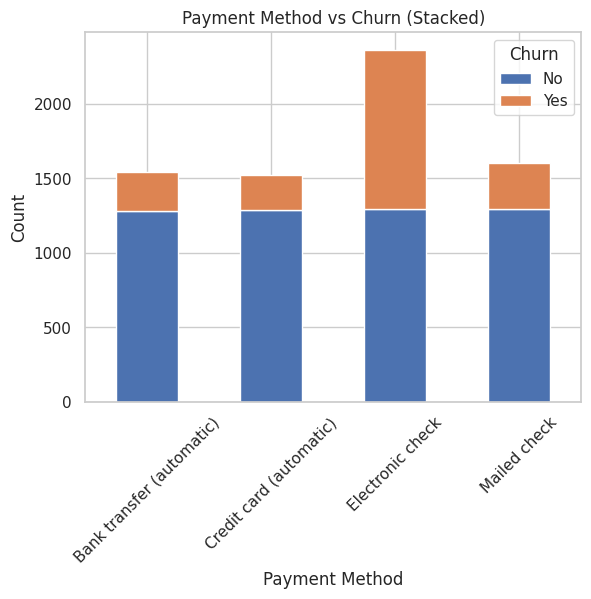

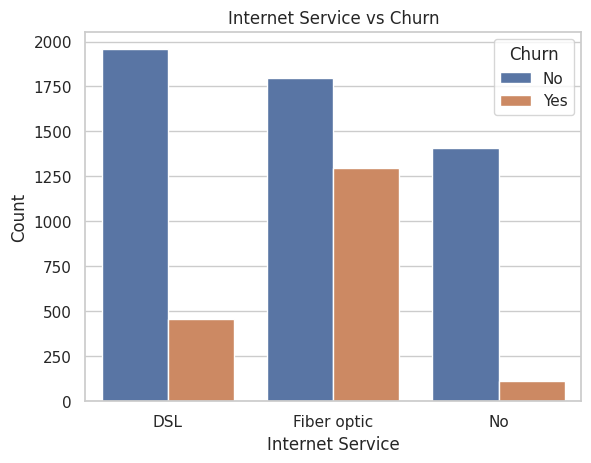

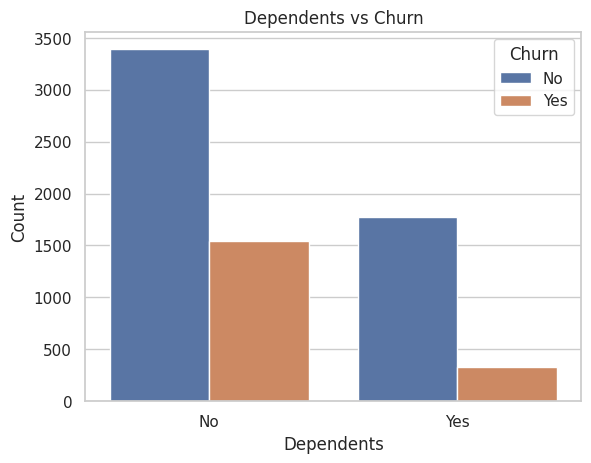

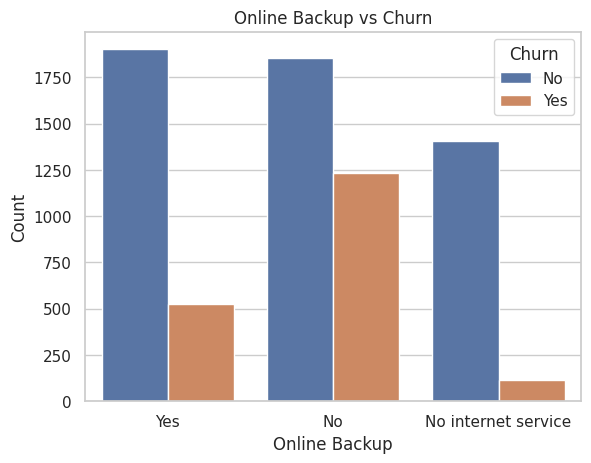

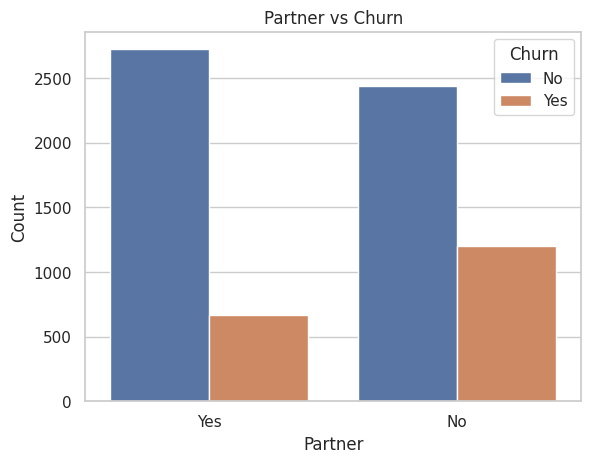

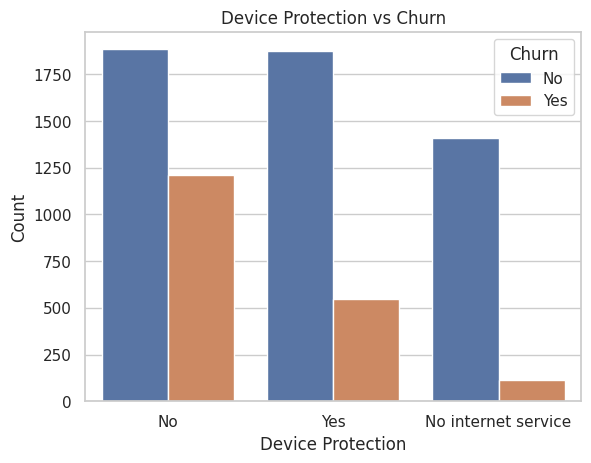

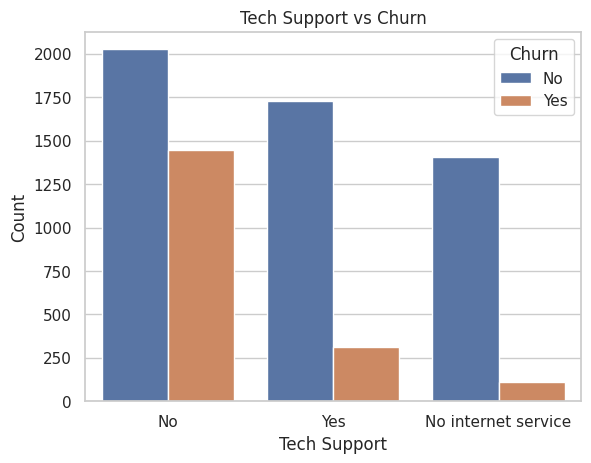

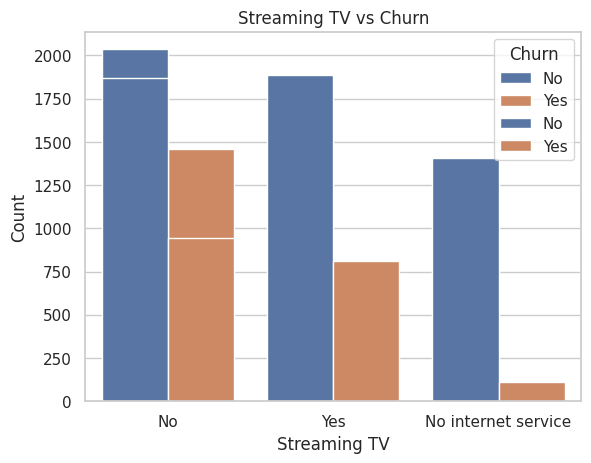

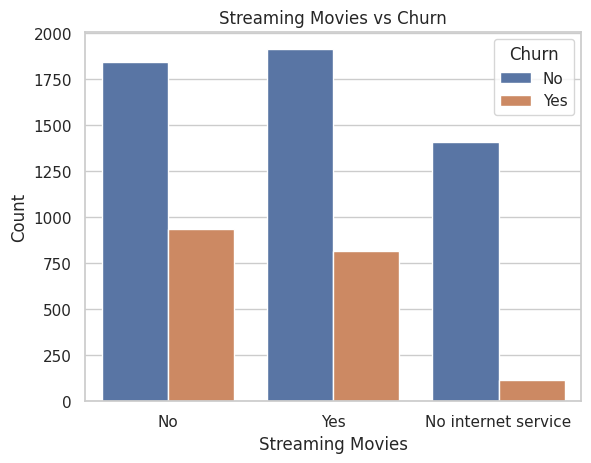

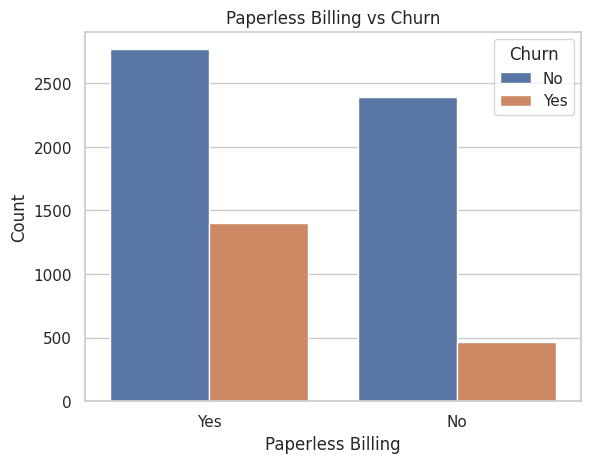

In [7]:
# Customer churn analysis-EDA
# objectives: Understand key factors influencing churn & Generate insights for model building.

#from google.colab import drive
#drive.mount('/content/drive')
#from google.colab import files
#uploaded = files.upload()
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")
#df = pd.read_csv('Telco-Customer-Churn-rawdata.csv')
#data overview
df.head()
df.info()
df.describe()
df.shape
df.isnull().sum()
df = df.replace(r'^\s*$', np.nan, regex=True)#replace blanks with NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')#convert to numeric
df = df[df['tenure'] != 0]#drop tenure with value = 0
df.isnull().sum()#make sure there are no null values in dataset, columns must be 0

#visual analysis
#plot 1: gender vs churn
sns.countplot(data=df, x='gender', hue='Churn')
plt.title('Gender vs Churn')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Churn')
plt.show()
#There is no significant difference in churn rate between male and female customers. About 40% of both male and female customers churn.

#plot 2:
sns.histplot(data=df, x='tenure', hue='Churn', bins=20, kde=True)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.show()
#Churn is significantly higher among customers with low tenure, while long-tenure customers are more likely to remain.

#plot 3:
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Contract Type vs Churn')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()
#Churn is highest among month-to-month customers, decreases for one-year contracts, and is lowest for two-year contracts

#plot 4:
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=20, kde=True)
plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Monthly Charges')
plt.ylabel('Count')
plt.show()

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue = 'Churn',palette='coolwarm', legend = 'auto')
plt.title('Monthly Charges vs Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()
#Customers with higher monthly charges are more likely to churn, while customers with lower charges tend to stay.

#plot 5:
sns.histplot(data=df, x='TotalCharges', hue='Churn', bins=20, kde=True)
plt.title('Total Charges Distribution by Churn')
plt.xlabel('Total Charges')
plt.ylabel('Count')
plt.show()
#Churn is concentrated among customers with low total charges, while customers with higher total charges tend to remain.

#plot6
# Create count table
ct = pd.crosstab(df['PaymentMethod'], df['Churn'])
# Plot stacked bar chart
ct.plot(kind='bar', stacked=True)
plt.title('Payment Method vs Churn (Stacked)')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Churn')
plt.show()
#Approximately half of the customers using electronic check payment methods churn, while customers using other payment methods exhibit much lower churn rates (around 10%).

#plot 7
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Internet Service vs Churn')
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.show()
#Customers using fiber optic internet have a significantly higher churn rate (around 70–80%) compared to other internet service types.

#plot 8
sns.countplot(data=df, x='Dependents', hue='Churn')
plt.title('Dependents vs Churn')
plt.xlabel('Dependents')
plt.ylabel('Count')
plt.show()
#Customers without dependents have a higher likelihood of churn, with nearly half of them churning.

#plot 8
sns.countplot(data=df, x='OnlineBackup', hue='Churn')
plt.title('Online Backup vs Churn')
plt.xlabel('Online Backup')
plt.ylabel('Count')
plt.show()
#Customers without online backup services are more likely to churn compared to those who have online backup.

#plot 9
sns.countplot(data=df,x='Partner', hue='Churn')
plt.title('Partner vs Churn')
plt.xlabel('Partner')
plt.ylabel('Count')
plt.show()
#Customers without a partner show higher churn rates, with nearly half of them churning.

#plot 10
sns.countplot(data=df, x='DeviceProtection', hue='Churn')
plt.title('Device Protection vs Churn')
plt.xlabel('Device Protection')
plt.ylabel('Count')
plt.show()
#Customers without device protection are more likely to churn than those who have device protection.

#plot 11
sns.countplot(data=df, x='TechSupport', hue='Churn')
plt.title('Tech Support vs Churn')
plt.xlabel('Tech Support')
plt.ylabel('Count')
plt.show()
#Customers without tech support are significantly more likely to churn.

#plot 12
sns.countplot(data=df, x='OnlineSecurity', hue='Churn')
plt.title('Online Security vs Churn')
plt.xlabel('Online Security')
plt.ylabel('Count')
#Customers who do not have online security services exhibit a high churn rate, with approximately 75% of such customers likely to churn.

#plot 13
sns.countplot(data=df, x='StreamingTV', hue='Churn')
plt.title('Streaming TV vs Churn')
plt.xlabel('Streaming TV')
plt.ylabel('Count')
plt.show()
#Customers who do not subscribe to streaming TV services exhibit a significantly higher churn rate (~75%) compared to those who do (~40%). Customers without internet service show the lowest likelihood of churn.

#plot 14
sns.countplot(data=df, x='StreamingMovies', hue='Churn')
plt.title('Streaming Movies vs Churn')
plt.xlabel('Streaming Movies')
plt.ylabel('Count')
plt.show()
#Churn rates are approximately equal (~50%) for customers regardless of whether they subscribe to streaming movie services. However, customers without internet service again demonstrate the lowest churn tendency.

#plot 16
sns.countplot(data=df, x='PaperlessBilling', hue='Churn')
plt.title('Paperless Billing vs Churn')
plt.xlabel('Paperless Billing')
plt.ylabel('Count')
plt.show()
#Customers using paperless billing have higher churn rates, with nearly half of them churning.
